In [1]:
library(tidyverse)

library(grid)
library(gridExtra)
library(patchwork)

source("../evaluation_utils/plots_eda.R")
source("../evaluation_utils/evaluation_funcs.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
cbPalette <- c("#CC79A7", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00")

# Load data

central_corrected === fedRBE corrected data

In [3]:
data_path <- "../evaluation_data/ecoli/"

central_uncorrected <- read.csv(paste0(data_path, "before/central_intensities_log_UNION.tsv"), sep = "\t", header = TRUE, row.names = 1, check.names = F)
metadata <- read.csv(paste0(data_path, "before/initial_data/central_batch_info.tsv"), sep = "\t", header = TRUE, row.names = 1)

central_corrected <- read.csv(paste0(data_path, "after/intensities_log_Rcorrected_UNION.tsv"), sep = "\t", header = TRUE, row.names = 1, check.names = F)
fed_corrected <- read.csv(paste0(data_path, "after/FedApp_corrected_data.tsv"), sep = "\t", header = TRUE, row.names = 1, check.names = F)

# remove X from row names
# rownames(metadata) <- gsub("X", "", rownames(metadata))
metadata$file <- rownames(metadata)
# order the columns in intensity dataframes
central_corrected <- central_corrected[, rownames(metadata)]

central_uncorrected <- central_uncorrected[rownames(central_corrected), rownames(metadata)]
fed_corrected <- fed_corrected[rownames(central_corrected), rownames(metadata)]

cat("Loaded data\n")
cat("Central uncorrected:", nrow(central_uncorrected), "rows\n")
cat("Central corrected:", nrow(central_corrected), "rows\n")
cat("Fed corrected:", nrow(fed_corrected), "rows\n")
cat("Sample metadata:", nrow(metadata), "rows\n\n")

Loaded data
Central uncorrected: 2702 rows
Central corrected: 2702 rows
Fed corrected: 2702 rows
Sample metadata: 118 rows



# Checks

## Diagnostic plots

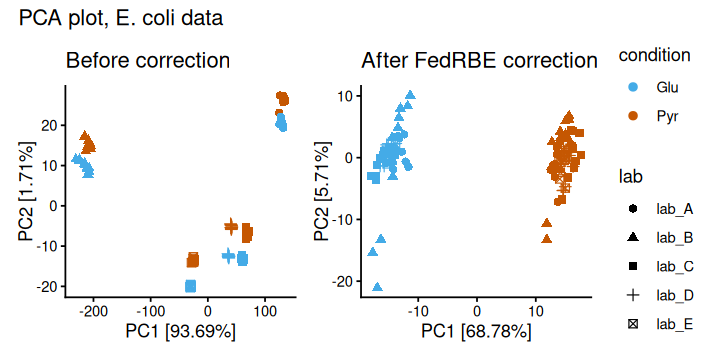

In [4]:
pca_plot_uncorrected <- pca_plot(central_uncorrected, metadata, 
    title = paste("Before correction"),
    quantitative_col_name = "file", col_col = "condition", shape_col="lab", show_legend=F, cbPalette=c("#44abe7", "#c55702"))
pca_plot_fed <- pca_plot(fed_corrected, metadata, 
    title = paste("After FedRBE correction"),
        quantitative_col_name = "file", col_col = "condition", shape_col="lab", show_legend=T, cbPalette=c("#44abe7", "#c55702"))

layout <- (pca_plot_uncorrected + pca_plot_fed)
layout <- layout + plot_annotation("PCA plot, E. coli data")
options(repr.plot.width=6, repr.plot.height=3)
layout

##  Linear model per variable

Following batch effect correction, the percentage of variance explained by the condition should be greater than the batch.

In [5]:
library(variancePartition)

Loading required package: limma

Loading required package: BiocParallel


Attaching package: ‘variancePartition’


The following objects are masked from ‘package:limma’:

    eBayes, topTable




In [6]:
form <- ~ condition + lab

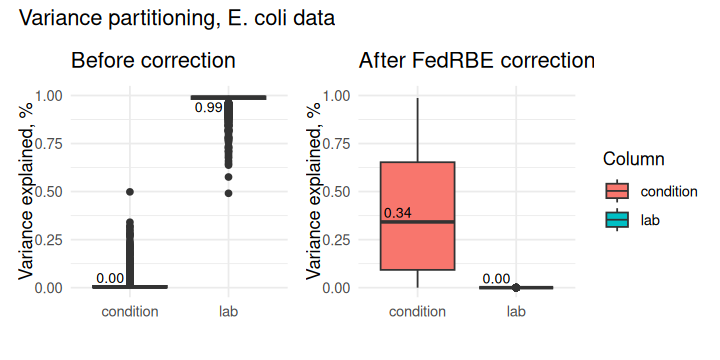

In [7]:
lmpv_plot_fed <- lmpv_plot(fed_corrected, metadata, 
    title = paste("After FedRBE correction"), form = form)
lmpv_plot_uncorrected <- lmpv_plot(central_uncorrected, metadata, 
    title = paste("Before correction"), show_legend=F, form = form)
    

layout <- (lmpv_plot_uncorrected + lmpv_plot_fed) 
layout <- layout + plot_annotation("Variance partitioning, E. coli data")
options(repr.plot.width=6, repr.plot.height=3)
layout

# Session info

In [8]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya-cosybio/miniforge3/envs/fedRBE_v2/lib/libmkl_rt.so.3;  LAPACK version 3.12.1

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] variancePartition_1.40.1 BiocParallel_1.44.0      limma_3.66.0            
 [4] viridis_0.6.5            viridisLite_0.4.3        ggsci_5.0.0             
 [7] umap_0.2.10.0            patchwork_1.3.2          gr